<a href="https://colab.research.google.com/github/Saadmoquim/physicscode/blob/main/PHY421_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem 1**, simple harmonic oscillator analysed under different schemes.

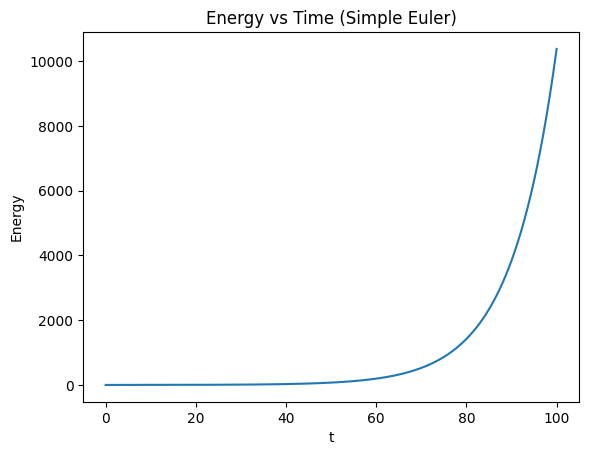

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
dt = 0.1
T = 100
N = int(T/dt)

t = np.linspace(0, T, N)
x = np.zeros(N)
v = np.zeros(N)

# Initial conditions
x[0] = 1
v[0] = 0

# Forward Euler, non energy conserving
for i in range(N-1):
    x[i+1] = x[i] + dt*v[i]
    v[i+1] = v[i] - dt*x[i]

# Energy
E = 0.5*(x**2 + v**2)

# Plot energy
plt.plot(t, E)
plt.title("Energy vs Time (Simple Euler)")
plt.xlabel("t")
plt.ylabel("Energy")
plt.show()


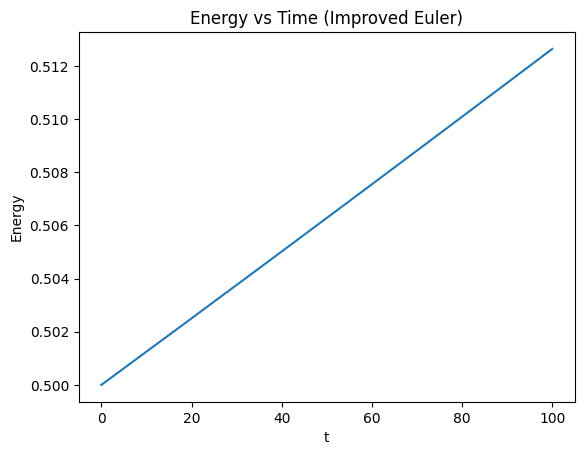

In [6]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
T = 100
N = int(T/dt)

t = np.linspace(0, T, N)
x = np.zeros(N)
v = np.zeros(N)

# Initial conditions
x[0] = 1
v[0] = 0

#improved euler, also not energy conserving
for i in range(N-1):
    # Predictor
    x_star = x[i] + dt*v[i]
    v_star = v[i] - dt*x[i]

    # Corrector
    x[i+1] = x[i] + dt*(v[i] + v_star)/2
    v[i+1] = v[i] + dt*(-x[i] - x_star)/2

E = 0.5*(x**2 + v**2)

plt.plot(t, E)
plt.title("Energy vs Time (Improved Euler)")
plt.xlabel("t")
plt.ylabel("Energy")
plt.show()


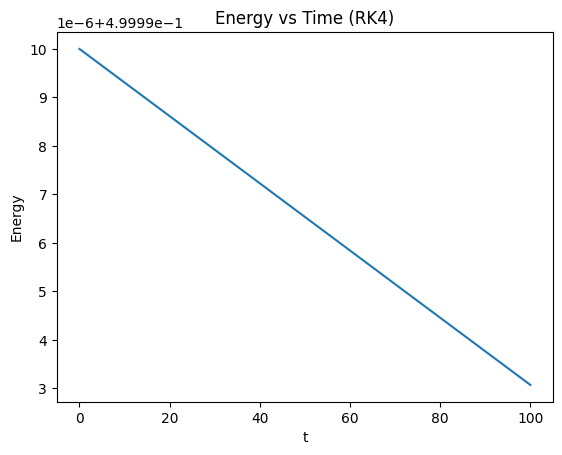

In [7]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
T = 100
N = int(T/dt)

t = np.linspace(0, T, N)
x = np.zeros(N)
v = np.zeros(N)

x[0] = 1
v[0] = 0

#RK4 solution, also not energy conserving
def f(x, v):
    return v, -x

for i in range(N-1):
    k1x, k1v = f(x[i], v[i])
    k2x, k2v = f(x[i] + dt*k1x/2, v[i] + dt*k1v/2)
    k3x, k3v = f(x[i] + dt*k2x/2, v[i] + dt*k2v/2)
    k4x, k4v = f(x[i] + dt*k3x, v[i] + dt*k3v)

    x[i+1] = x[i] + dt*(k1x + 2*k2x + 2*k3x + k4x)/6
    v[i+1] = v[i] + dt*(k1v + 2*k2v + 2*k3v + k4v)/6

E = 0.5*(x**2 + v**2)

plt.plot(t, E)
plt.title("Energy vs Time (RK4)")
plt.xlabel("t")
plt.ylabel("Energy")
plt.show()


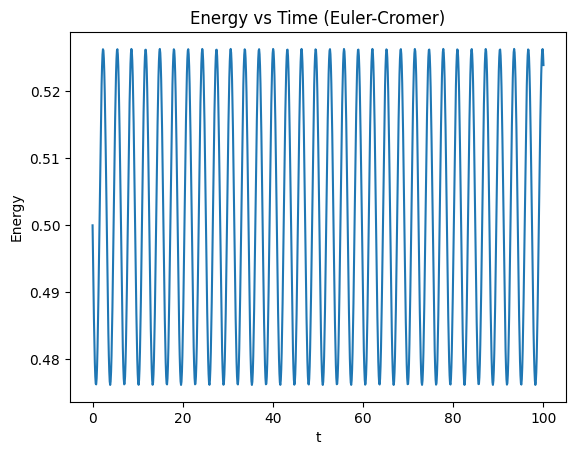

In [8]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
T = 100
N = int(T/dt)

t = np.linspace(0, T, N)
x = np.zeros(N)
v = np.zeros(N)

x[0] = 1
v[0] = 0
#euler cromer, consrves energy
for i in range(N-1):
    v[i+1] = v[i] - dt*x[i]
    x[i+1] = x[i] + dt*v[i+1]

E = 0.5*(x**2 + v**2)

plt.plot(t, E)
plt.title("Energy vs Time (Euler-Cromer)")
plt.xlabel("t")
plt.ylabel("Energy")
plt.show()


**Problem 2**, flow field of a non linear system

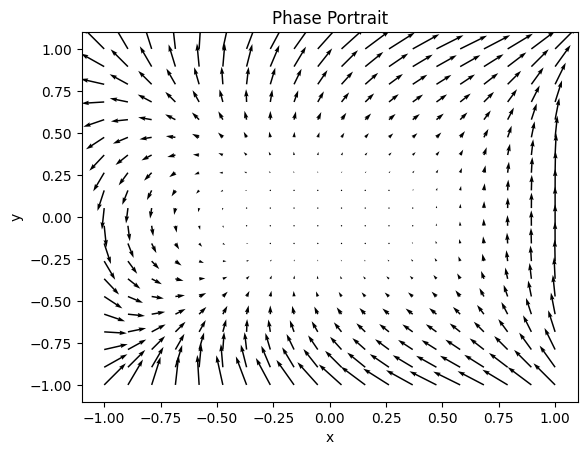

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    dx = x*y - x**2*y + y**3
    dy = y**2 + x**3 - x*y**2
    return dx, dy

x = np.linspace(-1,1,20)
y = np.linspace(-1,1,20)
X, Y = np.meshgrid(x,y)

DX, DY = f(X,Y)

plt.quiver(X, Y, DX, DY)
plt.title("Phase Portrait")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


/tmp/ipython-input-2493180026.py:7: RuntimeWarning: overflow encountered in scalar multiply
  dx = x*y - x**2*y + y**3
/tmp/ipython-input-2493180026.py:7: RuntimeWarning: overflow encountered in scalar power
  dx = x*y - x**2*y + y**3
/tmp/ipython-input-2493180026.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  dx = x*y - x**2*y + y**3
/tmp/ipython-input-2493180026.py:8: RuntimeWarning: overflow encountered in scalar power
  dy = y**2 + x**3 - x*y**2
/tmp/ipython-input-2493180026.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  dy = y**2 + x**3 - x*y**2


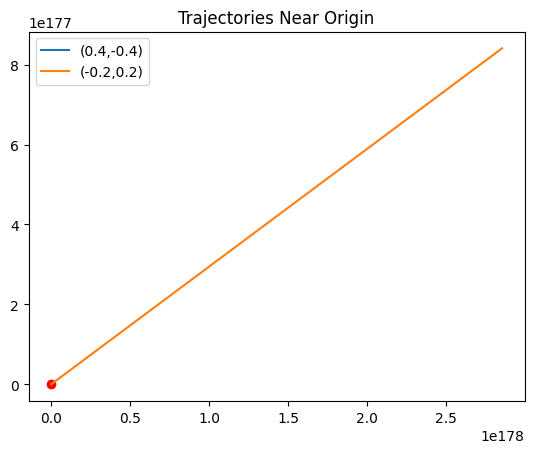

In [10]:
dt = 0.01
T = 20
N = int(T/dt)

def rk4_step(x, y):
    def f(x,y):
        dx = x*y - x**2*y + y**3
        dy = y**2 + x**3 - x*y**2
        return dx, dy

    k1x, k1y = f(x,y)
    k2x, k2y = f(x+dt*k1x/2, y+dt*k1y/2)
    k3x, k3y = f(x+dt*k2x/2, y+dt*k2y/2)
    k4x, k4y = f(x+dt*k3x, y+dt*k3y)

    x_new = x + dt*(k1x+2*k2x+2*k3x+k4x)/6
    y_new = y + dt*(k1y+2*k2y+2*k3y+k4y)/6

    return x_new, y_new


def integrate(x0, y0):
    x = np.zeros(N)
    y = np.zeros(N)
    x[0], y[0] = x0, y0

    for i in range(N-1):
        x[i+1], y[i+1] = rk4_step(x[i], y[i])

    return x, y


x1,y1 = integrate(0.4,-0.4)
x2,y2 = integrate(-0.2,0.2)

plt.plot(x1,y1,label="(0.4,-0.4)")
plt.plot(x2,y2,label="(-0.2,0.2)")
plt.scatter(0,0,color='red')
plt.legend()
plt.title("Trajectories Near Origin")
plt.show()


**Problem 3**, perform stability analysis: find the fixed points, eigen
vectors, and check the linear stability of the fixed points. Plot the phase portrait and check if
they are consistent with the results of the stability analysis.

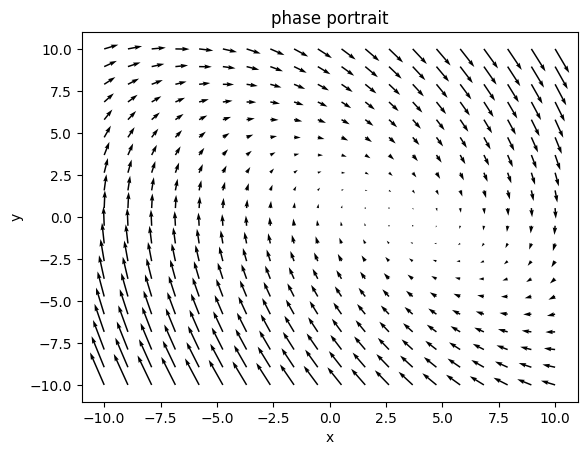

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
  dx=y
  dy=3-x-y
  return dx,dy

x=np.linspace(-10,10,20)
y=np.linspace(-10,10,20)
X,Y=np.meshgrid(x,y)
DX,DY=f(X,Y)

plt.quiver(X,Y,DX,DY)
plt.title("phase portrait")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

#as it can be seen in the plot, its a spiral converging to 3,0 which is consistent with the fixed point and the eigenvalues of the jacobian at the fixed point

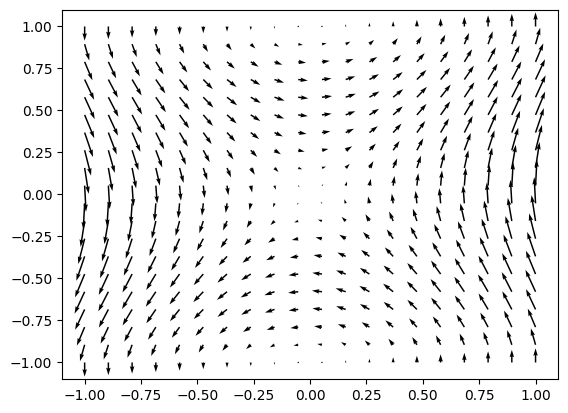

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
  dx=y-y**3
  dy=x*np.cos(y)
  return dx,dy

x=np.linspace(-1,1,20)
y=np.linspace(-1,1,20)
X,Y=np.meshgrid(x,y)
dx,dy=f(X,Y)

plt.quiver(X,Y,dx,dy)
plt.show()

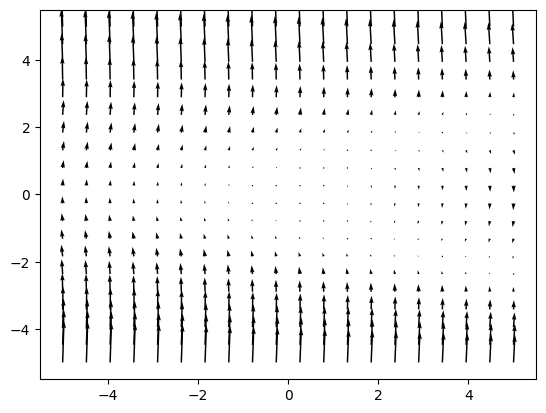

In [20]:
def f(x,y):
  dx=np.sin(y)
  dy=y**2-x
  return dx,dy

x=np.linspace(-5,5,20)
y=np.linspace(-5,5,20)
X,Y=np.meshgrid(x,y)
dx,dy=f(X,Y)

plt.quiver(X,Y,dx,dy)
plt.show()


**Problem 4**, plotting the phase portrait and overlay the trajectory of a phase point
by numerically solving the equations.

enter parameter value1


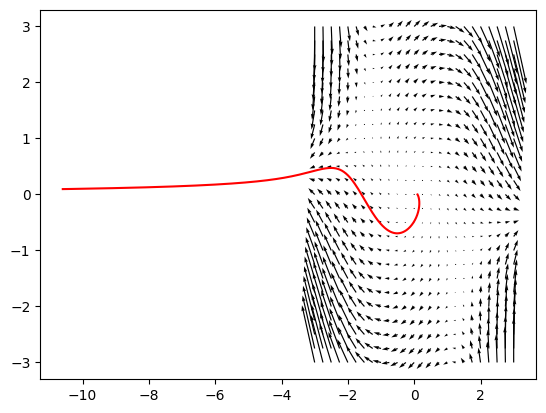

In [29]:
mu=float(input("enter parameter value"))

def f(x,y):
  dx=y+mu*x
  dy = -x + mu*y - x**2*y
  return dx,dy

x=np.linspace(-3,3,25)
y=np.linspace(-3,3,25)
X,Y=np.meshgrid(x,y)
dx,dy=f(X,Y)

def rk4(x,y,dt):
    k1x,k1y = f(x,y)
    k2x,k2y = f(x+dt*k1x/2,y+dt*k1y/2)
    k3x,k3y = f(x+dt*k2x/2,y+dt*k2y/2)
    k4x,k4y = f(x+dt*k3x,y+dt*k3y)

    x_new = x + dt*(k1x+2*k2x+2*k3x+k4x)/6
    y_new = y + dt*(k1y+2*k2y+2*k3y+k4y)/6

    return x_new,y_new

dt=0.001
x_traj,y_traj=[0.1],[0]

for i in range(5000):
    x_new,y_new = rk4(x_traj[-1],y_traj[-1],dt)
    x_traj.append(x_new)
    y_traj.append(y_new)

plt.plot(x_traj,y_traj,'r')
plt.quiver(X,Y,dx,dy)
plt.show()
#based on changing the mu values, it can be seen that this is a supercritical hopf bifurcation

enter parameter value-0.5


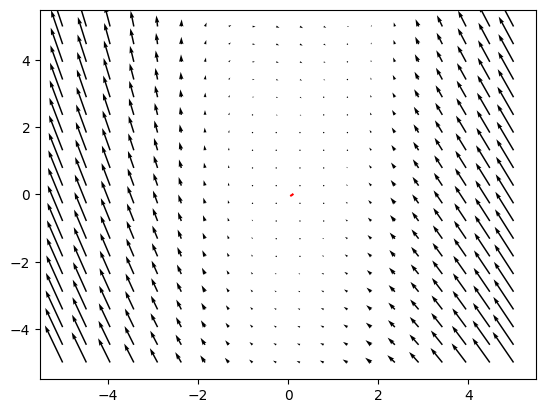

In [38]:
mu=float(input("enter parameter value"))
def f(x,y):
  dx=mu*x+y-x**2
  dy=-x+mu*y+2*x**2
  return dx,dy

x=np.linspace(-5,5,20)
y=np.linspace(-5,5,20)
X,Y=np.meshgrid(x,y)
dx,dy=f(X,Y)

def rk4(x,y,dt):
  kx1,ky1=f(x,y)
  kx2,ky2=f(x+kx1*dt/2,y+ky1*dt/2)
  kx3,ky3=f(x+kx2*dt/2,y+ky2*dt/2)
  kx4,ky4=f(x+kx3*dt,y+ky3*dt)

  x_new = x + dt*(kx1+2*kx2+2*kx3+kx4)/6
  y_new = y + dt*(ky1+2*ky2+2*ky3+ky4)/6

  return x_new,y_new

dt=0.0001
x_traj,y_traj=[0.1],[0]

for i in range(5000):
    x_new,y_new = rk4(x_traj[-1],y_traj[-1],dt)
    x_traj.append(x_new)
    y_traj.append(y_new)

plt.plot(x_traj,y_traj,'r')
plt.quiver(X,Y,dx,dy)
plt.show()

#also supercritical hopf

**Problem 5**, lorenz attractor analysis.

In [39]:
import numpy as np

# Parameters
sigma = 10
r = 28
b = 8/3

def f(x,y,z):
    dx = sigma*(y-x)
    dy = r*x - y - x*z
    dz = x*y - b*z
    return dx,dy,dz

def rk4(x,y,z,dt):
    k1 = np.array(f(x,y,z))
    k2 = np.array(f(x+dt*k1[0]/2, y+dt*k1[1]/2, z+dt*k1[2]/2))
    k3 = np.array(f(x+dt*k2[0]/2, y+dt*k2[1]/2, z+dt*k2[2]/2))
    k4 = np.array(f(x+dt*k3[0], y+dt*k3[1], z+dt*k3[2]))

    new = np.array([x,y,z]) + dt*(k1+2*k2+2*k3+k4)/6
    return new

# Initial conditions
dt = 0.01
steps = 50000
eps = 1e-8

X = np.array([1.0,1.0,1.0])
Xp = X + np.array([eps,0,0])

lyapunov_sum = 0

for i in range(steps):
    X = rk4(X[0],X[1],X[2],dt)
    Xp = rk4(Xp[0],Xp[1],Xp[2],dt)

    delta = Xp - X
    dist = np.linalg.norm(delta)

    lyapunov_sum += np.log(dist/eps)

    # renormalize
    delta = eps * delta/dist
    Xp = X + delta

lambda1 = lyapunov_sum/(steps*dt)
print("Largest Lyapunov exponent:", lambda1)

#i kinda coudnt figure out how to computationally do the fractal dimension calculation.Using kaplan yorke formula assuming that i know the lyapunov exponents, the dimension should be slightly greater than 2(2.06-.08)

Largest Lyapunov exponent: 0.8931241800025673


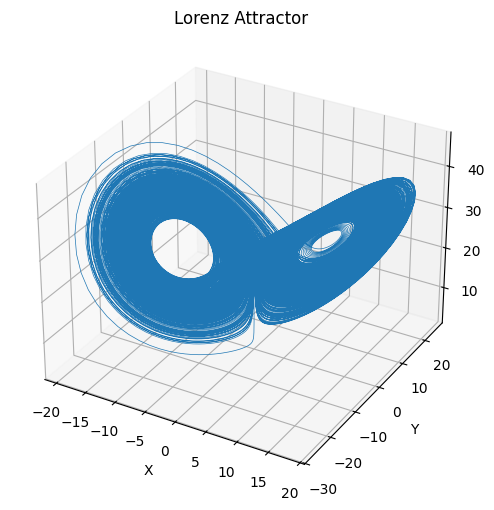

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
sigma = 10
r = 28
b = 8/3

def f(x,y,z):
    dx = sigma*(y-x)
    dy = r*x - y - x*z
    dz = x*y - b*z
    return dx,dy,dz

def rk4(x,y,z,dt):
    k1 = np.array(f(x,y,z))
    k2 = np.array(f(x+dt*k1[0]/2, y+dt*k1[1]/2, z+dt*k1[2]/2))
    k3 = np.array(f(x+dt*k2[0]/2, y+dt*k2[1]/2, z+dt*k2[2]/2))
    k4 = np.array(f(x+dt*k3[0], y+dt*k3[1], z+dt*k3[2]))

    new = np.array([x,y,z]) + dt*(k1+2*k2+2*k3+k4)/6
    return new

# Integration settings
dt = 0.01
steps = 50000

X = np.zeros((steps,3))
X[0] = [1.0, 1.0, 1.0]

# Integrate
for i in range(steps-1):
    X[i+1] = rk4(X[i,0], X[i,1], X[i,2], dt)

# Remove transient
X_plot = X[5000:]

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(X_plot[:,0], X_plot[:,1], X_plot[:,2], lw=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Lorenz Attractor")

plt.show()
